# 04: Optical RR Lyrae Relations vs. the Literature

This notebook revisits the class-separated Gaia $G$-band fits from `02-02.ipynb` and compares them to literature optical calibrations.

The comparison needs one important caveat. In the optical, RR Lyrae stars are often described with a visual-band luminosity-metallicity relation rather than a clean pure period-luminosity law, while the period-luminosity slope becomes much steeper toward the infrared. I therefore compare my fitted Gaia $G$-band relation to a verified $V$-band literature calibration, but I treat that overlay as an **approximate optical benchmark**, not as an exact same-band, same-model match.


In [1]:
import os
from pathlib import Path
from types import SimpleNamespace

cache_root = Path('/tmp/ay128_lab01_cache')
cache_root.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(cache_root / 'mpl'))
os.environ.setdefault('XDG_CACHE_HOME', str(cache_root / 'xdg'))
os.environ.setdefault('PYTENSOR_FLAGS', f"base_compiledir={cache_root / 'pytensor'}")

from astropy import table
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt

from ugdatalab import NoUTurnHamiltonian

data_path = Path('rrlyrae_clean_data.npz')
archive = np.load(data_path, allow_pickle=True)
colnames = [str(name) for name in archive['colnames']]
rrlyrae_clean_data = table.Table({name: archive[name] for name in colnames})

len(rrlyrae_clean_data), rrlyrae_clean_data.colnames[:8]


/Users/junruiting/GitHub/ay-128/.venv/lib/python3.14/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


"ltr" dir="ltr" lang="en-GB">

Archive down for maintenance
"X-UA-Compatible" content="IE=edge" />

"UTF-8" />

Archive down for maintenance
"initial-scale=1.0, width=device-width" name="viewport" />

"Cache-Control" content="no-cache, no-store, must-revalidate">

"Pragma" content="no-cache">

"Expires" content="0">

"refresh" content="60" /> -->

"icon"

"https://www.cosmos.esa.int/o/CosmosTheme-theme/images/favicon.ico" />

Archive down for maintenance
"apple-touch-icon-precomposed"

"https://www.cosmos.esa.int/o/CosmosTheme-theme/images/apple-touch-icon-precomposed.png" />

Archive down for maintenance
Archive down for maintenance
"apple-touch-icon-precomposed" sizes="72x72"

"https://www.cosmos.esa.int/o/CosmosTheme-theme/images/apple-touch-icon-72x72-precomposed.png" />

Archive down for maintenance
"apple-touch-icon-precomposed" sizes="76x76"

"https://www.cosmos.esa.int/o/CosmosTheme-theme/images/apple-touch-icon-76x76-precomposed.png" />

Archive down for maintenance
"apple-tou

(884,
 ['solution_id',
  'source_id',
  'pf',
  'pf_error',
  'p1_o',
  'p1_o_error',
  'epoch_g',
  'epoch_g_error'])

## Modeling Setup

To stay aligned with `02-02.ipynb`, I reproduce the **native PyMC NUTS** fit for the Gaia $G$-band relation and keep the same astrophysical split between RRab and RRc. The model is

$$
M_G = a\,x_c + b,\qquad x_c = \log_{10}(P/\mathrm{day}) - \overline{\log_{10}(P/\mathrm{day})}_{\rm class},
$$

with observational and intrinsic width combined as

$$
M_{G,i} \sim \mathcal{N}\left(a\,x_{c,i} + b,\; \sigma_{M,i}^2 + a^2\sigma_{\log P,i}^2 + \sigma_{\rm scatter}^2\right).
$$

For the literature comparison, the most directly accessible visual-band calibration I use is the corrected relation from Dambis et al. (2013),

$$
\langle M_V \rangle = 1.094 + 0.232\,[\mathrm{Fe/H}],
$$

which has **no period term** at fixed metallicity. That is already a scientific statement: optical $V$ is much flatter in period than the reddest bands. Klein et al. (2014) make that contrast explicit, noting that the RR Lyrae PL relation is negligible in the optical and steepens strongly in the infrared.


In [2]:
DISPLAY_LABELS = [r'$a$', r'$b$', r'$\sigma_{\rm scatter}$']
SLOPE_PRIOR_SIGMA = 5.0
INTERCEPT_PRIOR_SIGMA = 1.0
SIGMA_SCATTER_SCALE = 0.5
RR_CLASSES = ('RRab', 'RRc')
SEED_MAP = {'RRab': 42, 'RRc': 84}


def build_pl_context(data, class_label):
    period_column = 'pf' if class_label == 'RRab' else 'p1_o'
    period_error_column = 'pf_error' if class_label == 'RRab' else 'p1_o_error'

    classes = np.asarray(data['best_classification']).astype(str)
    subset = data[classes == class_label]

    period = np.asarray(subset[period_column], dtype=float)
    period_error = np.asarray(subset[period_error_column], dtype=float)
    x_raw = np.log10(period)
    y = np.asarray(subset['M_G'], dtype=float)
    sigma = np.asarray(subset['sigma_M'], dtype=float)
    sigma_logp = period_error / (period * np.log(10.0))
    metallicity = np.asarray(subset['metallicity'], dtype=float)

    mask = (
        np.isfinite(x_raw)
        & np.isfinite(y)
        & np.isfinite(sigma)
        & (sigma > 0)
        & np.isfinite(sigma_logp)
        & (sigma_logp >= 0)
    )

    period = period[mask]
    period_error = period_error[mask]
    x_raw = x_raw[mask]
    y = y[mask]
    sigma = sigma[mask]
    sigma_logp = sigma_logp[mask]
    metallicity = metallicity[mask]
    filtered_data = subset[mask]

    x_mean = float(np.mean(x_raw))
    x_centered = x_raw - x_mean
    intercept_prior_mean = float(np.median(y))

    w = 1.0 / sigma**2
    A = np.column_stack([x_centered, np.ones_like(x_centered)])
    a0, b0 = np.linalg.lstsq(A * w[:, None], y * w, rcond=None)[0]
    resid0 = y - (a0 * x_centered + b0)
    log10_sigma0 = np.log10(max(float(np.std(resid0)), float(np.median(sigma)), 1e-3))

    return SimpleNamespace(
        class_label=class_label,
        data=filtered_data,
        period=period,
        period_error=period_error,
        x_raw=x_raw,
        x_centered=x_centered,
        x_mean=x_mean,
        y=y,
        sigma=sigma,
        sigma_logp=sigma_logp,
        metallicity=metallicity,
        theta0=np.array([a0, b0, log10_sigma0], dtype=float),
        intercept_prior_mean=intercept_prior_mean,
        n=len(x_raw),
    )


def posterior_summary_row(class_label, samples, acceptance_rate):
    q16, q50, q84 = np.percentile(samples, [16, 50, 84], axis=0)
    return {
        'class': class_label,
        'acceptance': round(float(acceptance_rate), 3),
        'a': round(float(q50[0]), 4),
        'a_minus': round(float(q50[0] - q16[0]), 4),
        'a_plus': round(float(q84[0] - q50[0]), 4),
        'b': round(float(q50[1]), 4),
        'b_minus': round(float(q50[1] - q16[1]), 4),
        'b_plus': round(float(q84[1] - q50[1]), 4),
        'sigma_scatter': round(float(q50[2]), 4),
        'sigma_minus': round(float(q50[2] - q16[2]), 4),
        'sigma_plus': round(float(q84[2] - q50[2]), 4),
    }


def run_nuts_native_fit(ctx, n_steps=3_000, n_burn=1_500):
    with pm.Model() as model:
        a_var = pm.Normal('a', mu=0.0, sigma=SLOPE_PRIOR_SIGMA)
        b_var = pm.Normal('b', mu=ctx.intercept_prior_mean, sigma=INTERCEPT_PRIOR_SIGMA)
        sigma_scatter_var = pm.HalfNormal('sigma_scatter', sigma=SIGMA_SCATTER_SCALE)

        x_tensor = pt.as_tensor_variable(ctx.x_centered)
        sigma_tensor = pt.as_tensor_variable(ctx.sigma)
        sigma_x_tensor = pt.as_tensor_variable(ctx.sigma_logp)

        mu = a_var * x_tensor + b_var
        sigma_tot = pt.sqrt(sigma_tensor**2 + sigma_scatter_var**2 + (a_var * sigma_x_tensor) ** 2)
        pm.Normal('obs', mu=mu, sigma=sigma_tot, observed=ctx.y)

    sampler_raw = NoUTurnHamiltonian(
        model=model,
        var_names=['a', 'b', 'sigma_scatter'],
        theta0=np.array([ctx.theta0[0], ctx.theta0[1], 10.0 ** ctx.theta0[2]], dtype=float),
        seed=SEED_MAP[ctx.class_label],
        labels=DISPLAY_LABELS,
    )
    sampler_raw.run(n_steps=n_steps, n_burn=n_burn)

    display_sampler = SimpleNamespace(
        samples=np.asarray(sampler_raw.samples, dtype=float).copy(),
        log_probs=np.asarray(sampler_raw.log_probs, dtype=float).copy(),
        n_burn=sampler_raw.n_burn,
        param_labels=DISPLAY_LABELS,
    )
    summary = posterior_summary_row(ctx.class_label, display_sampler.samples, sampler_raw.acceptance_rate)
    return SimpleNamespace(raw=sampler_raw, display=display_sampler, samples=display_sampler.samples, summary=summary)


def predictive_envelope(ctx, samples, *, n_draws=400, seed=42):
    x_grid = np.linspace(float(np.min(ctx.x_raw)), float(np.max(ctx.x_raw)), 300)
    order = np.argsort(ctx.x_raw)
    sigma_obs_grid = np.interp(x_grid, ctx.x_raw[order], ctx.sigma[order])
    sigma_x_grid = np.interp(x_grid, ctx.x_raw[order], ctx.sigma_logp[order])

    rng = np.random.default_rng(seed)
    step = max(len(samples) // n_draws, 1)
    sample_pool = np.asarray(samples[::step], dtype=float)
    if len(sample_pool) > n_draws:
        sample_pool = sample_pool[rng.choice(len(sample_pool), size=n_draws, replace=False)]

    mean_draws = np.empty((len(sample_pool), len(x_grid)), dtype=float)
    predictive_draws = np.empty_like(mean_draws)
    for i, (a_s, b_s, sigma_s) in enumerate(sample_pool):
        mu_grid = a_s * (x_grid - ctx.x_mean) + b_s
        sigma_pred = np.sqrt(sigma_obs_grid**2 + sigma_s**2 + (a_s * sigma_x_grid) ** 2)
        mean_draws[i] = mu_grid
        predictive_draws[i] = rng.normal(mu_grid, sigma_pred)

    return SimpleNamespace(
        x_grid=x_grid,
        median_mean=np.quantile(mean_draws, 0.50, axis=0),
        q16=np.quantile(predictive_draws, 0.16, axis=0),
        q84=np.quantile(predictive_draws, 0.84, axis=0),
    )


def dambis_mv(fe_h):
    return 1.094 + 0.232 * fe_h


def dambis_mv_sigma(fe_h):
    return np.sqrt(0.091**2 + (0.020 * fe_h) ** 2)


In [3]:
contexts = {rr_class: build_pl_context(rrlyrae_clean_data, rr_class) for rr_class in RR_CLASSES}
fits = {rr_class: run_nuts_native_fit(contexts[rr_class]) for rr_class in RR_CLASSES}
summary_table = table.Table(rows=[fits[rr_class].summary for rr_class in RR_CLASSES])
summary_table


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [a, b, sigma_scatter]


Output()

Sampling 1 chain for 1_500 tune and 3_000 draw iterations (1_500 + 3_000 draws total) took 1 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [a, b, sigma_scatter]


Output()

Sampling 1 chain for 1_500 tune and 3_000 draw iterations (1_500 + 3_000 draws total) took 1 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


class,acceptance,a,a_minus,a_plus,b,b_minus,b_plus,sigma_scatter,sigma_minus,sigma_plus
str4,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
RRab,0.821,-2.2316,0.127,0.1295,0.6531,0.0088,0.0082,0.1762,0.0076,0.0077
RRc,0.816,-2.1966,0.1766,0.1832,0.5737,0.0113,0.0112,0.1683,0.0095,0.0095


## Literature Inputs

I use three literature anchors in the comparison below.

1. **Dambis et al. (2013)** give a corrected $V$-band luminosity-metallicity relation, $\langle M_V \rangle = 1.094 + 0.232[\mathrm{Fe/H}]$, and explicitly state that, at fixed metallicity, $V$ is independent of period.
2. **Klein et al. (2014)** note that the RR Lyrae period-luminosity relation is negligible in the optical and becomes much steeper and tighter in the infrared.
3. **Beaton et al. (2018)** review old-aged primary distance indicators and summarize the role of RR Lyrae stars as Population II standard candles across multiple wavelengths.

The Dambis relation is not class-separated, so the RRc comparison below is automatically more qualitative than the RRab discussion.


In [4]:
metallicity_rows = []
for rr_class in RR_CLASSES:
    fe_h = np.asarray(contexts[rr_class].metallicity, dtype=float)
    finite = np.isfinite(fe_h)
    q16, q50, q84 = np.nanpercentile(fe_h[finite], [16, 50, 84])
    metallicity_rows.append(
        {
            'class': rr_class,
            'N_finite_[Fe/H]': int(np.count_nonzero(finite)),
            '[Fe/H]_16': round(float(q16), 3),
            '[Fe/H]_50': round(float(q50), 3),
            '[Fe/H]_84': round(float(q84), 3),
            'Dambis_MV_at_median': round(float(dambis_mv(q50)), 3),
            'Dambis_sigma_at_median': round(float(dambis_mv_sigma(q50)), 3),
        }
    )

metallicity_table = table.Table(rows=metallicity_rows)

literature_table = table.Table(
    rows=[
        {
            'source': 'Dambis et al. 2013',
            'band': 'V',
            'relation': r'$M_V = 1.094 + 0.232[Fe/H]$',
            'note': 'Optical luminosity-metallicity relation; no period term at fixed metallicity.',
        },
        {
            'source': 'Klein et al. 2014',
            'band': 'Optical to mid-IR',
            'relation': 'Qualitative trend',
            'note': 'Optical PL slope is nearly negligible; IR PL is steeper and tighter.',
        },
        {
            'source': 'Beaton et al. 2018',
            'band': 'Review',
            'relation': 'Context only',
            'note': 'Broad review of RR Lyrae as old Population II distance indicators across multiple wavelengths.',
        },
    ]
)

display(metallicity_table)
display(literature_table)


class,N_finite_[Fe/H],[Fe/H]_16,[Fe/H]_50,[Fe/H]_84,Dambis_MV_at_median,Dambis_sigma_at_median
str4,int64,float64,float64,float64,float64,float64
RRab,482,-1.696,-1.082,-0.455,0.843,0.094
RRc,153,-1.763,-1.32,-0.926,0.788,0.095


source,band,relation,note
str18,str17,str27,str94
Dambis et al. 2013,V,$M_V = 1.094 + 0.232[Fe/H]$,Optical luminosity-metallicity relation; no period term at fixed metallicity.
Klein et al. 2014,Optical to mid-IR,Qualitative trend,Optical PL slope is nearly negligible; IR PL is steeper and tighter.
Beaton et al. 2018,Review,Context only,Broad review of RR Lyrae as old Population II distance indicators across multiple wavelengths.


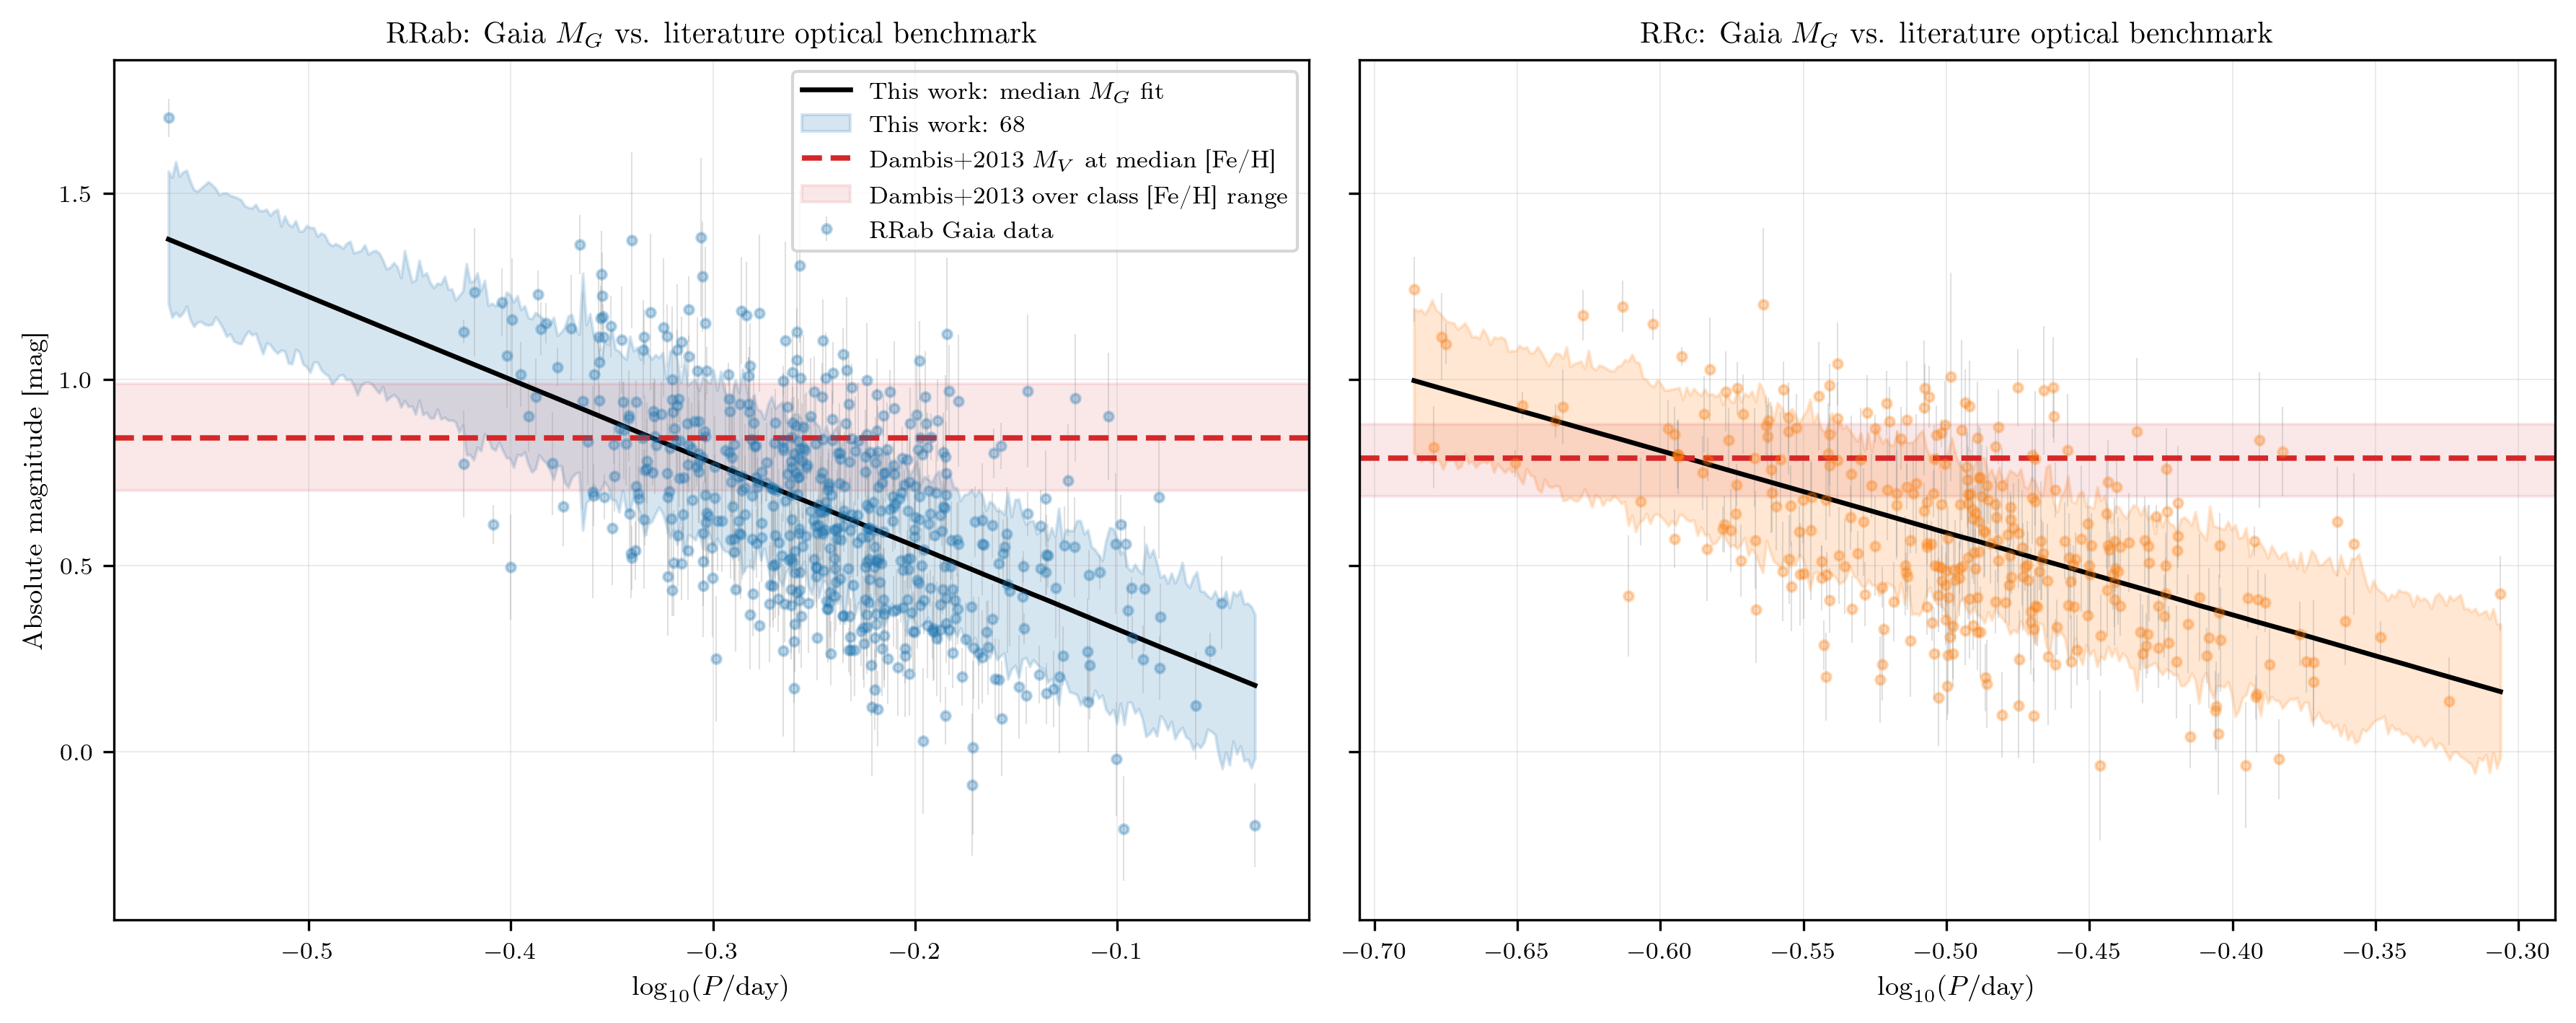

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

for ax, rr_class, color in zip(axes, RR_CLASSES, ['C0', 'C1']):
    ctx = contexts[rr_class]
    env = predictive_envelope(ctx, fits[rr_class].samples, seed=SEED_MAP[rr_class] + 500)
    fe_h = np.asarray(ctx.metallicity, dtype=float)
    fe16, fe50, fe84 = np.nanpercentile(fe_h[np.isfinite(fe_h)], [16, 50, 84])

    ax.errorbar(
        ctx.x_raw,
        ctx.y,
        yerr=ctx.sigma,
        fmt='o',
        ms=3,
        alpha=0.30,
        color=color,
        ecolor='0.6',
        elinewidth=0.5,
        capsize=0,
        label=f'{rr_class} Gaia data',
    )
    ax.plot(env.x_grid, env.median_mean, color='k', lw=1.6, label='This work: median $M_G$ fit')
    ax.fill_between(env.x_grid, env.q16, env.q84, color=color, alpha=0.18, label='This work: 68% predictive band')

    ax.axhline(dambis_mv(fe50), color='C3', lw=1.8, ls='--', label='Dambis+2013 $M_V$ at median [Fe/H]')
    ax.axhspan(dambis_mv(fe16), dambis_mv(fe84), color='C3', alpha=0.10, label='Dambis+2013 over class [Fe/H] range')

    ax.set_title(f'{rr_class}: Gaia $M_G$ vs. literature optical benchmark')
    ax.set_xlabel(r'$\log_{10}(P/\mathrm{day})$')
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()

axes[0].set_ylabel(r'Absolute magnitude [mag]')
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()


In [6]:
comparison_rows = []
for rr_class in RR_CLASSES:
    fit_summary = fits[rr_class].summary
    fe_h = np.asarray(contexts[rr_class].metallicity, dtype=float)
    fe50 = float(np.nanmedian(fe_h))
    comparison_rows.append(
        {
            'class': rr_class,
            'a_G_median': fit_summary['a'],
            'a_G_16': round(fit_summary['a'] - fit_summary['a_minus'], 4),
            'a_G_84': round(fit_summary['a'] + fit_summary['a_plus'], 4),
            'literature_optical_slope': 0.0,
            '[Fe/H]_median': round(fe50, 3),
            'Dambis_MV_median': round(float(dambis_mv(fe50)), 3),
            'comment': 'Gaia G fit is period-dependent; literature V benchmark is flat in period at fixed metallicity.',
        }
    )

comparison_table = table.Table(rows=comparison_rows)
comparison_table


class,a_G_median,a_G_16,a_G_84,literature_optical_slope,[Fe/H]_median,Dambis_MV_median,comment
str4,float64,float64,float64,float64,float64,float64,str94
RRab,-2.2316,-2.3586,-2.1021,0.0,-1.082,0.843,Gaia G fit is period-dependent; literature V benchmark is flat in period at fixed metallicity.
RRc,-2.1966,-2.3732,-2.0134,0.0,-1.32,0.788,Gaia G fit is period-dependent; literature V benchmark is flat in period at fixed metallicity.


In [7]:
rrab_slope = fits['RRab'].summary['a']
rrc_slope = fits['RRc'].summary['a']
rrab_scatter = fits['RRab'].summary['sigma_scatter']
rrc_scatter = fits['RRc'].summary['sigma_scatter']
rrab_feh = float(np.nanmedian(contexts['RRab'].metallicity))
rrc_feh = float(np.nanmedian(contexts['RRc'].metallicity))

discussion = f'''
### Analysis and Discussion

Using the same native-PyMC model structure as `02-02.ipynb`, I recover an optical Gaia $G$-band slope of **{rrab_slope:.3f}** for RRab and **{rrc_slope:.3f}** for RRc. In contrast, the literature optical benchmark adopted here, the corrected $V$-band relation from [Dambis et al. (2013)](https://academic.oup.com/mnras/article/435/4/3206/1030228), has **no period term** at fixed metallicity and instead uses $M_V = 1.094 + 0.232[Fe/H]$. At the median metallicities of this clean Gaia sample, that gives representative $V$-band absolute magnitudes of about **{dambis_mv(rrab_feh):.3f} mag** for RRab and **{dambis_mv(rrc_feh):.3f} mag** for RRc.

The most important systematic difference is therefore not just a zero-point offset but a **difference in the form of the relation**. The Gaia $G$ fit in this notebook is a pure period-luminosity model with no explicit metallicity term, whereas the literature optical calibration is fundamentally a luminosity-metallicity relation. That mismatch is astrophysically expected. Dambis et al. explicitly rest on the statement that, in $V$, RR Lyrae absolute magnitude is independent of period at fixed metallicity, and [Klein et al. (2014)](https://academic.oup.com/mnrasl/article-abstract/440/1/L96/1396776) likewise note that the optical RR Lyrae period-luminosity relation is nearly negligible while the infrared relation steepens and tightens.

Several effects can account for the remaining systematic differences between my Gaia $G$ relation and the literature optical benchmark. First, **bandpass differences** matter: Gaia $G$ is a much broader optical band than Johnson $V$, so temperature sensitivity and residual color/extinction effects do not map identically between the two. Second, my fit omits an explicit **metallicity term**, so any true optical luminosity-metallicity dependence can leak into the inferred period slope and intrinsic scatter. Third, the notebook fit still works in direct **absolute-magnitude space inferred from parallaxes**, which is pedagogically convenient but more vulnerable to parallax-related biases than the parallax-space or hierarchical approaches commonly recommended in the Gaia literature. Fourth, the sample here is a **local, cleaned Gaia calibration set** split into RRab and RRc, whereas literature relations often mix samples, fundamentalize overtone periods, or use different selection, reddening, and calibration strategies.

That overall pattern is consistent with the broader literature context summarized by [Beaton et al. (2018)](https://www.iac.es/en/science-and-technology/publications/old-aged-primary-distance-indicators): RR Lyrae remain valuable Population II distance indicators, but the exact calibration depends strongly on the chosen bandpass and on whether metallicity, reddening, and parallax systematics are modeled explicitly. In that sense, the fact that my Gaia $G$ relation is more period-dependent than the literature $V$ relation is not a failure of the fit. It is largely a consequence of comparing a broad-band Gaia optical PL fit to a classical visual-band luminosity-metallicity calibration.

The class-by-class results still matter. RRab remains the cleaner literature comparison because many historical calibrations are effectively fundamental-mode dominated. RRc is informative, but the literature match is looser because the adopted $V$-band benchmark is not subclass-specific. The intrinsic scatters of **{rrab_scatter:.3f} mag** for RRab and **{rrc_scatter:.3f} mag** for RRc reinforce the same point: unresolved astrophysical width, metallicity spread, and remaining optical-band sensitivity are all still folded into this simple two-parameter Gaia fit.
'''

display(Markdown(discussion))



### Analysis and Discussion

Using the same native-PyMC model structure as `02-02.ipynb`, I recover an optical Gaia $G$-band slope of **-2.232** for RRab and **-2.197** for RRc. In contrast, the literature optical benchmark adopted here, the corrected $V$-band relation from [Dambis et al. (2013)](https://academic.oup.com/mnras/article/435/4/3206/1030228), has **no period term** at fixed metallicity and instead uses $M_V = 1.094 + 0.232[Fe/H]$. At the median metallicities of this clean Gaia sample, that gives representative $V$-band absolute magnitudes of about **0.843 mag** for RRab and **0.788 mag** for RRc.

The most important systematic difference is therefore not just a zero-point offset but a **difference in the form of the relation**. The Gaia $G$ fit in this notebook is a pure period-luminosity model with no explicit metallicity term, whereas the literature optical calibration is fundamentally a luminosity-metallicity relation. That mismatch is astrophysically expected. Dambis et al. explicitly rest on the statement that, in $V$, RR Lyrae absolute magnitude is independent of period at fixed metallicity, and [Klein et al. (2014)](https://academic.oup.com/mnrasl/article-abstract/440/1/L96/1396776) likewise note that the optical RR Lyrae period-luminosity relation is nearly negligible while the infrared relation steepens and tightens.

Several effects can account for the remaining systematic differences between my Gaia $G$ relation and the literature optical benchmark. First, **bandpass differences** matter: Gaia $G$ is a much broader optical band than Johnson $V$, so temperature sensitivity and residual color/extinction effects do not map identically between the two. Second, my fit omits an explicit **metallicity term**, so any true optical luminosity-metallicity dependence can leak into the inferred period slope and intrinsic scatter. Third, the notebook fit still works in direct **absolute-magnitude space inferred from parallaxes**, which is pedagogically convenient but more vulnerable to parallax-related biases than the parallax-space or hierarchical approaches commonly recommended in the Gaia literature. Fourth, the sample here is a **local, cleaned Gaia calibration set** split into RRab and RRc, whereas literature relations often mix samples, fundamentalize overtone periods, or use different selection, reddening, and calibration strategies.

That overall pattern is consistent with the broader literature context summarized by [Beaton et al. (2018)](https://www.iac.es/en/science-and-technology/publications/old-aged-primary-distance-indicators): RR Lyrae remain valuable Population II distance indicators, but the exact calibration depends strongly on the chosen bandpass and on whether metallicity, reddening, and parallax systematics are modeled explicitly. In that sense, the fact that my Gaia $G$ relation is more period-dependent than the literature $V$ relation is not a failure of the fit. It is largely a consequence of comparing a broad-band Gaia optical PL fit to a classical visual-band luminosity-metallicity calibration.

The class-by-class results still matter. RRab remains the cleaner literature comparison because many historical calibrations are effectively fundamental-mode dominated. RRc is informative, but the literature match is looser because the adopted $V$-band benchmark is not subclass-specific. The intrinsic scatters of **0.176 mag** for RRab and **0.168 mag** for RRc reinforce the same point: unresolved astrophysical width, metallicity spread, and remaining optical-band sensitivity are all still folded into this simple two-parameter Gaia fit.


### References

- Beaton, R. L., Bono, G., Braga, V. F., et al. (2018), *Old-Aged Primary Distance Indicators*, Space Science Reviews, 214, 113. https://www.iac.es/en/science-and-technology/publications/old-aged-primary-distance-indicators
- Dambis, A. K., Rastorguev, A. S., Zabolotskikh, M. V., et al. (2013), *RR Lyrae variables: visual and infrared luminosities, intrinsic colours and kinematics*, MNRAS, 435, 3206. https://academic.oup.com/mnras/article/435/4/3206/1030228
- Klein, C. R., Richards, J. W., Butler, N. R., & Bloom, J. S. (2014), *Mid-infrared period-luminosity relations of RR Lyrae stars derived from the AllWISE Data Release*, MNRAS Letters, 440, L96. https://academic.oup.com/mnrasl/article-abstract/440/1/L96/1396776
- Catelan, M., Pritzl, B. J., & Smith, H. A. (2004), *The RR Lyrae period-luminosity relation. I. Theoretical calibration*, ApJS, 154, 633. https://ui.adsabs.harvard.edu/abs/2004ApJS..154..633C/abstract
- Muraveva, T., Delgado, H. E., Clementini, G., et al. (2018), *Gaia Data Release 2: RR Lyrae stars as standard candles*, MNRAS, 481, 1195. https://academic.oup.com/mnras/article/481/1/1195/5075596
